# 02 — Approximation, Clustering and Matrix Profile

Three linked questions, answered in order:

1. **Approximation** — can 200 time steps be compressed to 40 without losing
   the shape? (PAA)
2. **Clustering** — do the compressed signals fall into recognisable groups of
   daily routine? (DTW k-means and hierarchical clustering)
3. **Matrix profile** — inside each group's average shape, which subsequences
   repeat (motifs) and which stand alone (discords)?

This notebook is entirely **unsupervised**: the labels are never used.

Equivalent to: `python main.py --stage cluster`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

from src.clustering import (analyze_centroid_matrix_profiles, build_dtw_input,
                            cluster_hierarchical_dtw, cluster_kmeans_dtw,
                            compute_cluster_centroids,
                            compute_dtw_distance_matrix, compute_paa,
                            plot_centroid_diagnostics,
                            plot_cluster_count_search,
                            plot_cluster_projections, project_pca,
                            project_tsne, search_cluster_count)
from src.utils import load_prepared_arrays

## 1. Load the prepared arrays

Written by notebook 01. Shape is `(subjects, time steps, features)`.

In [2]:
X_train, _, _, _ = load_prepared_arrays()
print(f"Loaded a 3D array of shape {X_train.shape}.")

Loaded a 3D array of shape (3549, 200, 8).


## 2. Piecewise Aggregate Approximation

PAA cuts each series into equal-width segments and replaces each with its mean.
It is the cheapest useful time-series approximation: high-frequency noise
disappears, the length drops 5x, and the overall shape survives.

That length reduction is what makes the next step affordable — DTW over 3,549
subjects is quadratic in both the number of subjects and the series length.

In [3]:
paa_3d, paa_flat = compute_paa(X_train)

PAA Approximation complete!
3D PAA Shape: (3549, 40, 8)
Flattened PAA Shape for linear models: (3549, 320)


## 3. How many clusters?

Two complementary views of the same question, both on plain (Euclidean)
k-means, which is fast enough to sweep:

- **Elbow** — inertia always falls as k grows, so look for where it stops
  falling quickly.
- **Silhouette** — rewards clusters that are tight and well separated, so look
  for the peak.

The silhouette scores here are all low (around 0.1), which is itself a result:
the subjects do not fall into cleanly separated groups. Seven clusters is used
below as a descriptive partition, not as a claim about natural structure.

Evaluating cluster numbers...
k = 2 | Inertia: 677752.45 | Silhouette Score: 0.1050
k = 3 | Inertia: 632928.61 | Silhouette Score: 0.0995
k = 4 | Inertia: 596064.33 | Silhouette Score: 0.1058
k = 5 | Inertia: 574217.61 | Silhouette Score: 0.0907
k = 6 | Inertia: 557633.61 | Silhouette Score: 0.0908
k = 7 | Inertia: 527901.49 | Silhouette Score: 0.0956
k = 8 | Inertia: 527691.13 | Silhouette Score: 0.0577
k = 9 | Inertia: 512453.46 | Silhouette Score: 0.0622
k = 10 | Inertia: 500303.55 | Silhouette Score: 0.0666


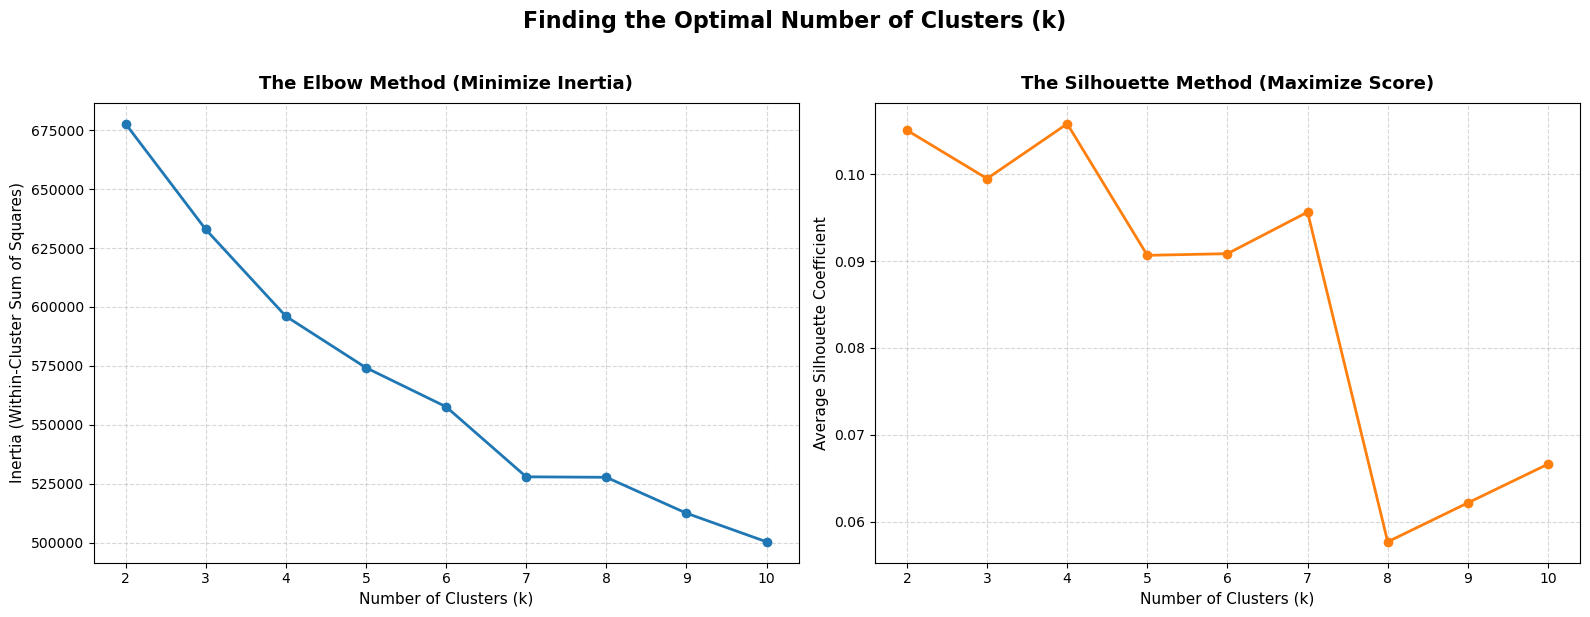

In [4]:
inertia_values, silhouette_scores = search_cluster_count(paa_flat)

plot_cluster_count_search(inertia_values, silhouette_scores)

## 4. Clustering with Dynamic Time Warping

DTW stretches and compresses the time axis to find the best alignment between
two series, so two children with the same routine shifted by an hour still
count as similar — the right notion of similarity for daily behaviour that is
not perfectly synchronised. The Sakoe-Chiba band caps how far the alignment may
drift, which keeps the cost tractable.

**A note on the input shape.** `build_dtw_input` hands DTW the *flattened* PAA
matrix: the eight channels stay concatenated end to end and are treated as a
single 320-step univariate series per subject, rather than as 40 steps across 8
channels. Every number and centroid below was produced this way.

Two algorithms are run on the same distances:

- **k-means**, which averages members into a centroid in DTW space (DBA).
- **Hierarchical (average linkage)**, which merges the two clusters whose
  members are closest on average — more robust to one odd subject than single
  linkage, less biased toward equal-sized clusters than Ward.

Both cells are slow; the distance matrix is 3,549 x 3,549.

In [5]:
dtw_input = build_dtw_input(paa_flat)

kmeans_labels = cluster_kmeans_dtw(dtw_input)

Running DTW K-Means (Sakoe-Chiba constrained)...


In [6]:
distance_matrix = compute_dtw_distance_matrix(dtw_input)

hierarchical_labels = cluster_hierarchical_dtw(distance_matrix)

Computing pairwise DTW distance matrix for Hierarchical Clustering...
Running Hierarchical Clustering (Average Linkage on DTW distances)...


## 5. Visualising the clusters

Two projections, because either one alone can mislead:

- **PCA** is a global linear view — fast, and it preserves the directions of
  largest variance, but it measures similarity with Euclidean distance rather
  than the DTW distance the clusters were actually built on.
- **t-SNE with `metric="precomputed"`** lays out the real DTW space, so the
  picture matches the distance used to form the clusters. It preserves local
  neighbourhoods, not global distances — read cluster shapes, not the gaps
  between them.

Reading the 2x2 grid: agreement down a column means both algorithms found the
same structure; agreement across a row means that structure survives the change
of projection.


Running PCA dimensionality reduction (Global Linear Projection)...
Running t-SNE dimensionality reduction using Precomputed DTW distances...


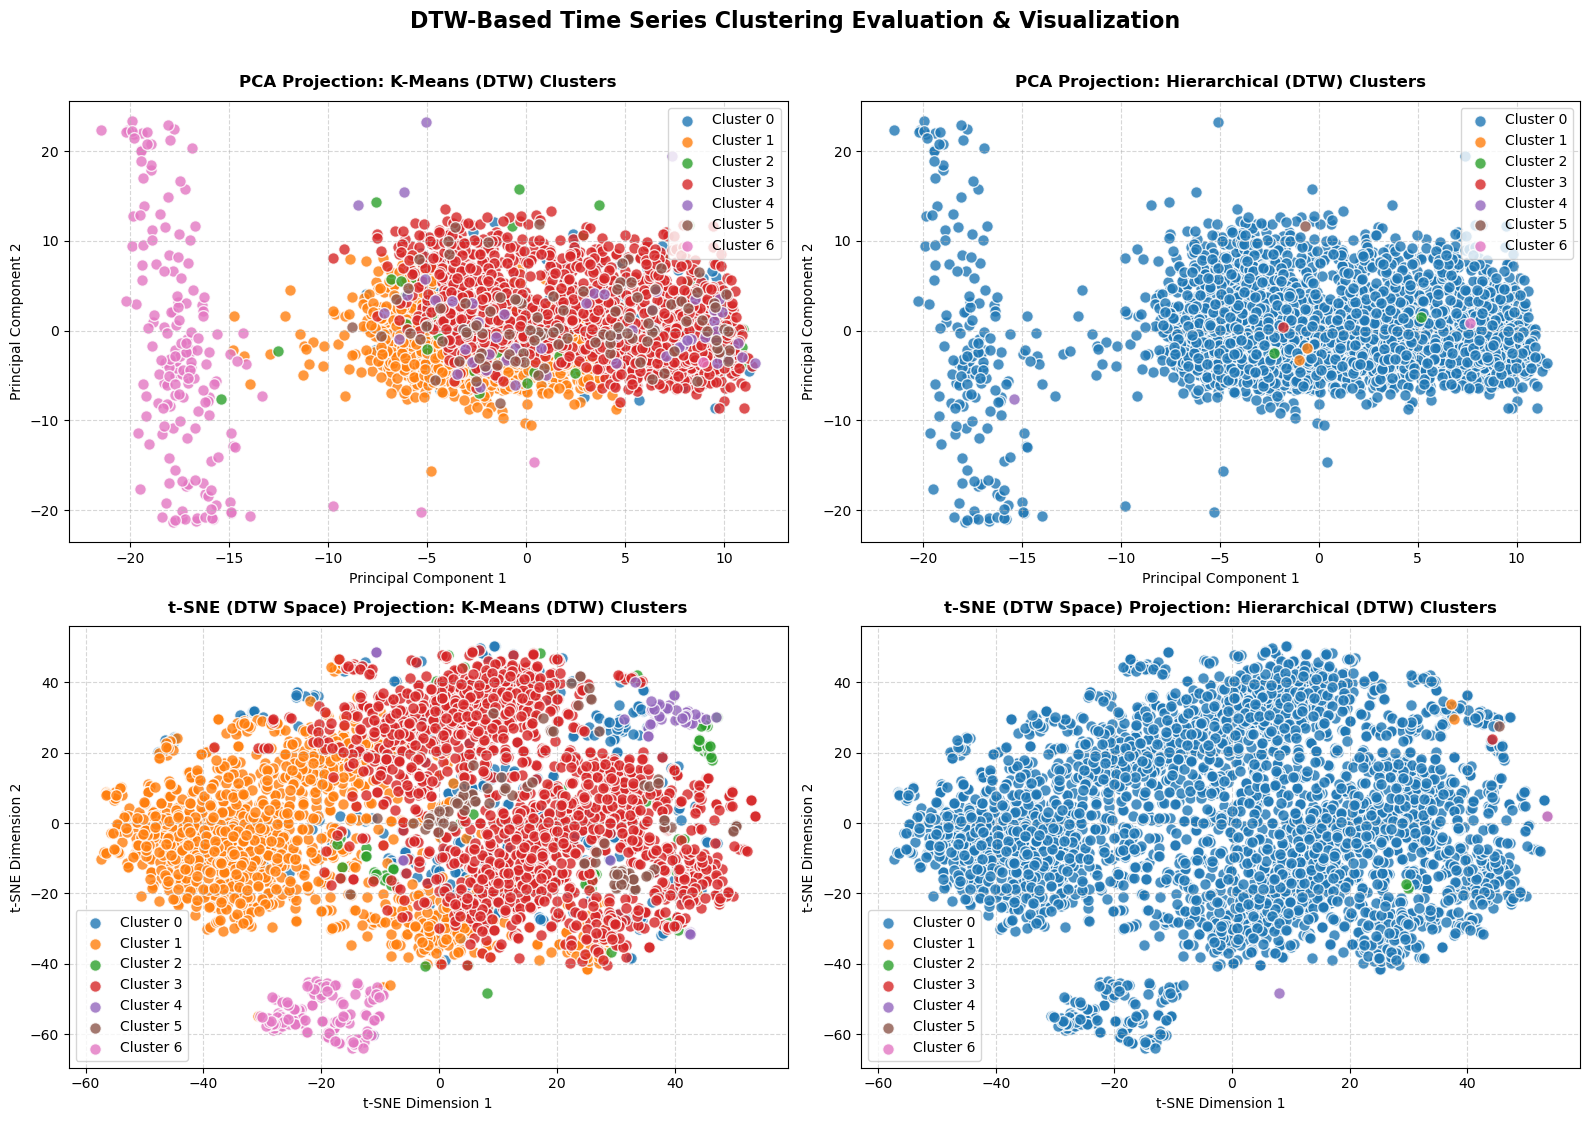

In [7]:
pca_points = project_pca(paa_flat)
tsne_points = project_tsne(distance_matrix)

plot_cluster_projections(pca_points, tsne_points, kmeans_labels,
                         hierarchical_labels)

## 6. Matrix profile: motifs and discords

Each cluster is collapsed to one average shape, and the matrix profile is
computed over it. For every subsequence of length `m = 30`, the profile stores
the distance to its closest match elsewhere in the same series:

- **low** values mark **motifs** — behaviour that recurs;
- **high** values mark **discords** — behaviour that happens once.

After each discord is picked, an exclusion zone of half a window is blanked out
so the next rank cannot be a near-duplicate of the one just found.

In [8]:
centroids = compute_cluster_centroids(dtw_input, kmeans_labels)

analyze_centroid_matrix_profiles(centroids)

Computing cluster centroids from saved labels...
Successfully computed centroids. Shape: (7, 320)

ANALYZING CLUSTER CENTROID 0
Top Motifs Found:
  Rank 1: Subsequence starts at index 197 (Distance: 0.0000)

Top 5 Anomalies (Discords) Found:
  Rank 1: Subsequence starts at index 287 (Profile Distance: 5.3073)
  Rank 2: Subsequence starts at index 73 (Profile Distance: 3.4174)
  Rank 3: Subsequence starts at index 88 (Profile Distance: 3.3351)
  Rank 4: Subsequence starts at index 105 (Profile Distance: 3.1694)
  Rank 5: Subsequence starts at index 228 (Profile Distance: 3.1320)

ANALYZING CLUSTER CENTROID 1
Top Motifs Found:
  Rank 1: Subsequence starts at index 189 (Distance: 0.0000)

Top 5 Anomalies (Discords) Found:
  Rank 1: Subsequence starts at index 40 (Profile Distance: 2.2273)
  Rank 2: Subsequence starts at index 289 (Profile Distance: 1.8935)
  Rank 3: Subsequence starts at index 14 (Profile Distance: 1.8227)
  Rank 4: Subsequence starts at index 56 (Profile Distance: 1.6199

The diagnostic plot shows one centroid with its top motif pair (green) and top
discord (red) marked, above the matrix profile that produced them. Change
`cluster_index` to inspect any of the seven.

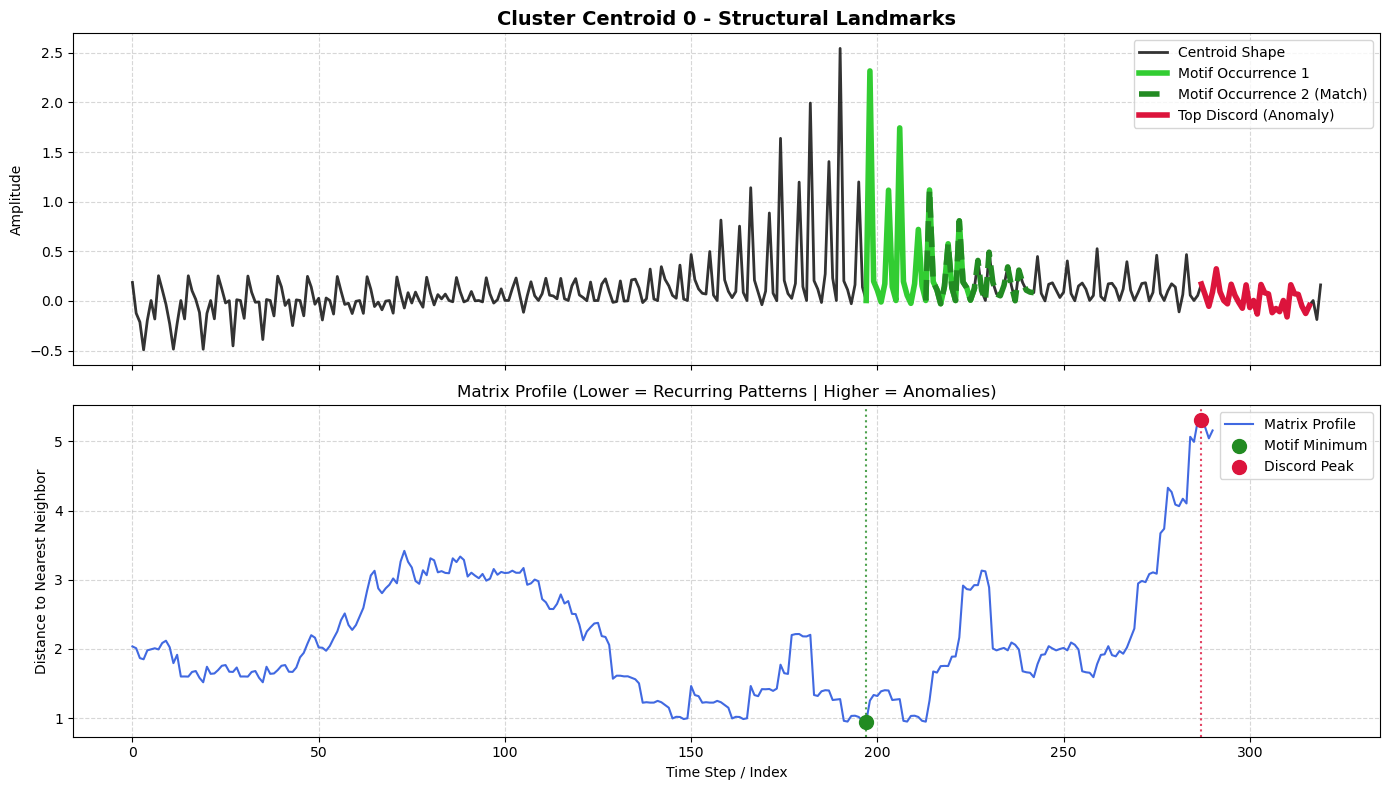

In [9]:
plot_centroid_diagnostics(centroids, cluster_index=0)